# 📊 **Google Play Store Dataset - Keşifsel Veri Analizi ve Özellik Mühendisliği**

## 🎯 Ders Genel Bakış

Bu notebook, **Yönetim Bilişim Sistemleri (YBS)** öğrencileri için hazırlanmış kapsamlı bir **Feature Engineering** ve **Exploratory Data Analysis (EDA)** çalışmasıdır. Gerçek dünya verisi olan Google Play Store uygulamaları üzerinde veri temizleme, dönüştürme ve analiz işlemlerini uygulamalı olarak öğreneceksiniz.

---

## 📚 Öğrenme Hedefleri

Bu notebook sonunda şunları yapabilir hale geleceksiniz:

> **🎓 Veri Temizleme Becerileri**
> - Veri tiplerini doğru şekilde dönüştürme
> - Eksik ve hatalı verileri tespit edip düzeltme
> - String manipülasyonu ile veri standardizasyonu

> **📊 Keşifsel Veri Analizi (EDA)**
> - Sayısal ve kategorik değişkenleri ayırt etme
> - Veri dağılımlarını görselleştirme ve yorumlama
> - İş değeri yaratan içgörüler çıkarma

> **🔧 Feature Engineering**
> - Mevcut sütunlardan yeni özellikler türetme
> - Tarih verilerinden zaman boyutları oluşturma
> - Kategorik verileri sayısal formata dönüştürme (Encoding)

> **💼 İş Zekası Perspektifi**
> - Veriyi iş kararlarına dönüştürme
> - Kategori bazlı performans analizi
> - Strateji geliştirme için veri kullanımı

---

## 🗺️ Analiz Süreci Genel Bakış

```mermaid
graph LR
    A[📥 Veri Yükleme] --> B[🔍 İlk Keşif]
    B --> C[🧹 Veri Temizleme]
    C --> D[🔧 Feature Engineering]
    D --> E[📊 EDA Analizi]
    E --> F[💼 İş İçgörüleri]
    F --> G[🎯 Model Hazırlığı]
    
    style A fill:#FFE5E5,stroke:#FF6B6B,stroke-width:2px
    style B fill:#FFF4E5,stroke:#FFB84D,stroke-width:2px
    style C fill:#E5F5FF,stroke:#4D94FF,stroke-width:2px
    style D fill:#F0E5FF,stroke:#9D4DFF,stroke-width:2px
    style E fill:#E5FFE5,stroke:#4DFF88,stroke-width:2px
    style F fill:#FFE5F5,stroke:#FF4D94,stroke-width:2px
    style G fill:#E5F5F0,stroke:#4DFFB8,stroke-width:2px
```

---

## 💼 YBS Perspektifinden Bu Çalışmanın Önemi

**Yönetim Bilişim Sistemleri** öğrencileri olarak, veri analizi becerileri şirketlerde şu rollerde karşınıza çıkacak:

- **📈 İş Analisti**: Uygulama verilerini analiz ederek ürün stratejisi geliştirme
- **💻 Veri Analisti**: Kullanıcı davranışlarını anlama ve raporlama
- **🎯 Ürün Yöneticisi**: Kategori performanslarını değerlendirme
- **🏢 İş Zekası Uzmanı**: Dashboard'lar için veri hazırlama ve görselleştirme

Bu çalışmada kullanacağımız teknikler, **gerçek iş problemlerini çözmek** için kullanılmaktadır.

---

📅 **Son Güncelleme:** Şubat 2026  
🏫 **Hedef Kitle:** YBS Öğrencileri  
📊 **Veri Kaynağı:** [Kaggle - Google Play Store Apps](https://www.kaggle.com/datasets/lava18/google-play-store-apps/)

## 1️⃣ **Kütüphanelerin Yüklenmesi ve Ortam Hazırlığı**

Veri analizi için gerekli Python kütüphanelerini içe aktarıyoruz. Her bir kütüphane farklı bir amaca hizmet eder:

## 📦 Kullanılacak Kütüphaneler

| Kütüphane | Amaç | YBS'de Kullanım Alanı |
|-----------|------|----------------------|
| **pandas** 🐼 | Veri manipülasyonu ve analizi | Excel benzeri tablolar üzerinde işlemler |
| **numpy** 🔢 | Matematiksel işlemler ve diziler | Büyük veri setlerinde hızlı hesaplamalar |
| **matplotlib** 📊 | Temel veri görselleştirme | Raporlar için statik grafikler |
| **seaborn** 🎨 | Gelişmiş istatistiksel grafikler | Profesyonel dashboard görselleri |

> **💡 YBS İpucu:** Bu kütüphaneler, iş analisti ve veri analisti pozisyonlarında en çok kullanılan araçlardır. SQL ile veriyi çektikten sonra, Python ile analiz edersiniz.

In [1]:
# Veri manipülasyonu ve analiz için temel kütüphane
import pandas as pd

# Matematiksel işlemler ve dizi operasyonları için
import numpy as np

# Veri görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin notebook içinde görünmesini sağlar
%matplotlib inline

# Grafik stilini ayarlama (profesyonel görünüm için)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Tüm kütüphaneler başarıyla yüklendi!")

✅ Tüm kütüphaneler başarıyla yüklendi!


## 2️⃣ **Veri Setinin Yüklenmesi ve İlk Keşif**

Google Play Store'dan toplanan gerçek uygulama verilerini yüklüyoruz.

## 📊 **Veri Seti Hakkında**

Bu veri seti, Google Play Store'daki **10,000'den fazla uygulamaya** ait bilgileri içerir:

- **Uygulama Özellikleri:** İsim, kategori, boyut, fiyat
- **Kullanıcı Metrikleri:** İnceleme sayısı, yükleme sayısı, derecelendirme
- **Teknik Detaylar:** Android versiyonu, içerik derecelendirmesi
- **Zaman Bilgisi:** Son güncellenme tarihi

> **💼 İş Senaryosu:**  
> Bir mobil uygulama şirketinin **Veri Analisti** olarak çalıştığınızı düşünün. Şirket CEO'su sizden Play Store'daki rakip uygulamaları analiz etmenizi ve **hangi kategorilerde hangi özelliklere sahip uygulamaların başarılı olduğunu** bulmanızı istiyor.

In [2]:
# Veri setini pandas DataFrame'e yükleme
# CSV (Comma-Separated Values) dosyası Excel gibi tablo formatındadır
df = pd.read_csv("17-googleplaystore.csv")

print("✅ Veri seti başarıyla yüklendi!")
print(f"📊 Toplam {df.shape[0]} satır ve {df.shape[1]} sütun bulunmaktadır.")

✅ Veri seti başarıyla yüklendi!
📊 Toplam 10841 satır ve 13 sütun bulunmaktadır.


## 🔍 **İlk 5 Satıra Göz Atalım**

`head()` fonksiyonu, veri setinin ilk birkaç satırını gösterir. Bu, verinin yapısını hızlıca anlamak için kullanılır.

In [3]:
# İlk 5 satırı görüntüleme
# Bu, veri setinin yapısını ve sütun içeriklerini anlamamıza yardımcı olur
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 📋 **Sütun İsimlerini İnceleyelim**

Veri setinde hangi bilgilerin bulunduğunu görmek için sütun isimlerini listeliyoruz.

In [4]:
# Tüm sütun isimlerini görüntüleme
# Her sütun, uygulamalar hakkında farklı bir bilgi içerir
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

## 📏 **Veri Setinin Boyutları**

`shape` özelliği bize (satır_sayısı, sütun_sayısı) formatında bilgi verir.

In [5]:
# Veri setinin boyutlarını öğrenme
# shape[0] = satır sayısı (uygulama sayısı)
# shape[1] = sütun sayısı (özellik sayısı)
print(f"📊 Veri Seti Boyutu: {df.shape}")
print(f"   • Toplam Uygulama Sayısı: {df.shape[0]:,}")
print(f"   • Toplam Özellik Sayısı: {df.shape[1]}")

📊 Veri Seti Boyutu: (10841, 13)
   • Toplam Uygulama Sayısı: 10,841
   • Toplam Özellik Sayısı: 13


## 🔬 **Veri Tipleri ve Bellek Kullanımı**

`info()` metodu, her sütunun veri tipini ve null olmayan değer sayısını gösterir. Bu bilgi **veri temizleme** aşamasında kritiktir.

In [6]:
# Veri seti hakkında detaylı bilgi
# - Her sütunun veri tipi (int, float, object)
# - Null (eksik) değer sayısı
# - Bellek kullanımı
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


> **⚠️ Dikkat Edilmesi Gerekenler:**
> - `object` tipi genellikle **metin** verisi anlamına gelir
> - Bazı sütunlarda **null (eksik) değerler** olabilir
> - Sayısal olması gereken sütunlar `object` tipinde ise **veri temizleme** gereklidir

## 📊 **İstatistiksel Özet**

`describe()` fonksiyonu, **sayısal sütunlar** için temel istatistiksel bilgileri verir.

In [7]:
# Sayısal sütunlar için istatistiksel özet
# - count: Veri sayısı
# - mean: Ortalama
# - std: Standart sapma
# - min, max: En küçük ve en büyük değerler
# - 25%, 50%, 75%: Çeyreklik değerler (quartiles)
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


## 🕵️ **Eksik Değerlerin Tespiti**

Eksik veriler (null/NaN) analiz kalitesini düşürür. İlk adım olarak hangi sütunlarda kaç adet eksik veri olduğunu tespit ediyoruz.

In [8]:
# Her sütundaki eksik değer sayısını hesaplama
# isnull(): Her hücrenin eksik olup olmadığını kontrol eder (True/False)
# sum(): True değerlerini sayar
missing_values = df.isnull().sum()

# Sadece eksik değeri olan sütunları göster
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("📉 Eksik Değer Analizi:")
print("=" * 50)
for col, count in missing_values.items():
    percentage = (count / len(df)) * 100
    print(f"   {col}: {count} eksik değer (%{percentage:.2f})")
    
if len(missing_values) == 0:
    print("   ✅ Hiç eksik değer yok!")

📉 Eksik Değer Analizi:
   Rating: 1474 eksik değer (%13.60)
   Current Ver: 8 eksik değer (%0.07)
   Android Ver: 3 eksik değer (%0.03)
   Content Rating: 1 eksik değer (%0.01)
   Type: 1 eksik değer (%0.01)


## 3️⃣ **Veri Temizleme - Reviews Sütunu**

İlk veri kalitesi sorununu tespit etme ve çözme aşaması. **Reviews** sütunu sayısal olmalı ama `object` tipinde görünüyor.

## 🔍 **Problem Tespiti**

```mermaid
graph TD
    A[Reviews Sütunu] --> B{Veri Tipi?}
    B -->|object metin| C[❌ SORUN!]
    B -->|int64 sayısal| D[✅ Normal]
    C --> E[Neden sayısal değil?]
    E --> F[Hatalı satır var mı?]
    F --> G[Temizlik gerekli]
    
    style A fill:#E5F5FF,stroke:#4D94FF,stroke-width:2px
    style C fill:#FFE5E5,stroke:#FF6B6B,stroke-width:2px
    style D fill:#E5FFE5,stroke:#4DFF88,stroke-width:2px
    style G fill:#FFF4E5,stroke:#FFB84D,stroke-width:2px
```

**Reviews** sütunu uygulama inceleme sayısını temsil eder ve **mutlaka sayısal** olmalıdır. Ancak veri tipi `object` (metin) olarak görünüyor.

In [9]:
# Reviews sütunundaki benzersiz değer sayısına bakalım
# Sorunlu değerleri tespit etmek için ilk adım
print(f"Reviews sütununda {df['Reviews'].nunique()} farklı değer var")
print(f"Veri tipi: {df['Reviews'].dtype}")

Reviews sütununda 6002 farklı değer var
Veri tipi: object


## 🧪 **Hangi Değerler Sayısal Değil?**

Python'da string (metin) metodlarını kullanarak her bir değerin sayısal olup olmadığını kontrol edebiliriz.

In [10]:
# str.isnumeric() metodu: String'in tamamen rakamlardan oluşup oluşmadığını kontrol eder
# Örnek: "123" -> True, "12.5" -> False, "12A" -> False

numeric_count = df["Reviews"].str.isnumeric().sum()
total_count = len(df["Reviews"])

print(f"📊 Sayısal değer analizi:")
print(f"   • Sayısal olan: {numeric_count} / {total_count}")
print(f"   • Sayısal olmayan: {total_count - numeric_count}")

📊 Sayısal değer analizi:
   • Sayısal olan: 10840 / 10841
   • Sayısal olmayan: 1


> **💡 Analiz Sonucu:**  
> 10,840 değer sayısal iken sadece **1 değer** sayısal değil. Bu tek hatalı satırı bulmamız gerekiyor.

## 🎯 Hatalı Satırı Bulma

`~` (tilde) operatörü, boolean (True/False) değerleri **tersine çevirir**.

In [11]:
# ~ operatörü: Boolean değerleri tersine çevirir
# True -> False, False -> True
# 
# df["Reviews"].str.isnumeric() -> Sayısal olanlar True
# ~df["Reviews"].str.isnumeric() -> Sayısal OLMAYANLAR True

hatalı_satırlar = df[~df["Reviews"].str.isnumeric()]

print("❌ Sayısal olmayan değere sahip satır(lar):")
print("=" * 80)
hatalı_satırlar

❌ Sayısal olmayan değere sahip satır(lar):


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


> **🔍 Tespit:**  
> İndeks 10472'deki satırda veri kayması var. Bu satırın tüm değerleri kaymış durumda ve veri bütünlüğü bozuk. Bu satırı **silmemiz** gerekiyor.

## 💾 **Veri Setinin Güvenli Kopyasını Oluşturma**

Orijinal veriyi korumak için **her zaman bir kopya üzerinde** çalışmalıyız.

In [12]:
# copy() metodu: DataFrame'in derin kopyasını oluşturur
# Böylece orijinal veri (df) değişmez, sadece df_clean üzerinde işlem yaparız
# Bu, hata yaptığımızda geri dönmemizi kolaylaştırır

df_clean = df.copy()

print("✅ Veri setinin güvenli kopyası 'df_clean' olarak oluşturuldu")
print(f"   Orijinal veri (df): {df.shape[0]} satır")
print(f"   Çalışma verisi (df_clean): {df_clean.shape[0]} satır")

✅ Veri setinin güvenli kopyası 'df_clean' olarak oluşturuldu
   Orijinal veri (df): 10841 satır
   Çalışma verisi (df_clean): 10841 satır


## 🗑️ **Hatalı Satırı Silme**

`drop()` fonksiyonu ile belirli satırları veri setinden çıkarabiliriz.

In [13]:
# Hatalı satırı silme
# df_clean.index[10472]: 10472. satırın index değerini verir
# drop(): Belirtilen index'teki satırı siler

df_clean = df_clean.drop(df_clean.index[10472])

print(f"✅ Hatalı satır silindi")
print(f"   Önceki satır sayısı: {df.shape[0]}")
print(f"   Yeni satır sayısı: {df_clean.shape[0]}")
print(f"   Silinen satır: 1")

✅ Hatalı satır silindi
   Önceki satır sayısı: 10841
   Yeni satır sayısı: 10840
   Silinen satır: 1


## ✅ **Temizlik Sonrası Kontrol**

Şimdi tüm değerlerin sayısal olduğunu doğrulayalım.

In [14]:
# Silme işlemi sonrası kontrol
# Artık tüm değerler sayısal olmalı
numeric_check = df_clean[~df_clean["Reviews"].str.isnumeric()]

if len(numeric_check) == 0:
    print("✅ Tüm Reviews değerleri artık sayısal!")
else:
    print("⚠️ Hala sayısal olmayan değerler var:")
    print(numeric_check)

✅ Tüm Reviews değerleri artık sayısal!


## 🔄 **Veri Tipi Dönüşümü**

Artık güvenle `object` tipini `int` (tam sayı) tipine dönüştürebiliriz.

In [15]:
# astype() metodu: Bir sütunun veri tipini değiştirir
# "123" (string) -> 123 (integer)
# Bu dönüşüm sayesinde matematiksel işlemler (ortalama, toplam vb.) yapabiliriz

df_clean["Reviews"] = df_clean["Reviews"].astype(int)

print("✅ Reviews sütunu integer tipine dönüştürüldü")
print(f"   Yeni veri tipi: {df_clean['Reviews'].dtype}")
print(f"\n📊 İstatistiksel bilgiler artık hesaplanabilir:")
print(f"   • Ortalama inceleme sayısı: {df_clean['Reviews'].mean():,.0f}")
print(f"   • En çok inceleme: {df_clean['Reviews'].max():,}")
print(f"   • En az inceleme: {df_clean['Reviews'].min():,}")

✅ Reviews sütunu integer tipine dönüştürüldü
   Yeni veri tipi: int64

📊 İstatistiksel bilgiler artık hesaplanabilir:
   • Ortalama inceleme sayısı: 444,153
   • En çok inceleme: 78,158,306
   • En az inceleme: 0


## 📊 **Güncellenmiş Veri Yapısı**

Temizlik sonrası veri tiplerini kontrol edelim.

In [16]:
# Veri tipleri ve null değerler güncellenmiş durumda
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.2+ MB


## 4️⃣ **Veri Temizleme - Size Sütunu**

**Size** (Boyut) sütunu, uygulamaların MB/KB cinsinden boyutlarını içerir. Ancak farklı birimler (M, k) ve metin değerler içerdiği için standardizasyon gerekiyor.

## 🔍 **Size Sütununun Mevcut Durumu**

Önce sütunda hangi değerlerin olduğunu inceleyelim.

In [17]:
# value_counts(): Her değerin kaç kez tekrarlandığını sayar
# En çok tekrar eden değerler üstte görünür

print("📊 Size sütunundaki değer dağılımı (ilk 20):")
print("=" * 60)
df_clean["Size"].value_counts().head(20)

📊 Size sütunundaki değer dağılımı (ilk 20):


Size
Varies with device    1695
11M                    198
12M                    196
14M                    194
13M                    191
15M                    184
17M                    160
19M                    154
26M                    149
16M                    149
25M                    143
20M                    139
21M                    138
10M                    136
24M                    136
18M                    133
23M                    117
22M                    114
29M                    103
27M                     97
Name: count, dtype: int64

In [18]:
# unique() metodu: Sütundaki benzersiz değerleri gösterir
# Bu, veri çeşitliliğini anlamamıza yardımcı olur

unique_sizes = df_clean["Size"].unique()
print(f"📊 Toplam {len(unique_sizes)} farklı boyut değeri var")
print("\n🔍 Örnek değerler:")
print(unique_sizes[:20])

📊 Toplam 461 farklı boyut değeri var

🔍 Örnek değerler:
['19M' '14M' '8.7M' '25M' '2.8M' '5.6M' '29M' '33M' '3.1M' '28M' '12M'
 '20M' '21M' '37M' '2.7M' '5.5M' '17M' '39M' '31M' '4.2M']


> **⚠️ Tespit Edilen Sorunlar:**
> - `"19M"`, `"14M"` gibi değerler → MB (Megabyte) cinsinden
> - `"12k"`, `"8.5k"` gibi değerler → KB (Kilobyte) cinsinden  
> - `"Varies with device"` → Cihaza göre değişir (standart değil)
> - Tüm değerler **string (metin)** formatında
>
> **🎯 Hedef:** Tüm boyutları **KB cinsine çevirmek** ve sayısal formata dönüştürmek

## 🔄 Birim Dönüşüm Stratejisi

```mermaid
graph LR
    A[Size Sütunu] --> B{Birim?}
    B -->|M Megabyte| C[M'yi 000 ile değiştir]
    B -->|k Kilobyte| D[k'yi sil]
    B -->|Varies with device| E[NaN yap]
    C --> F[String → Float]
    D --> F
    E --> F
    F --> G[✅ KB Cinsinden Sayısal Veri]
    
    style A fill:#E5F5FF,stroke:#4D94FF,stroke-width:2px
    style G fill:#E5FFE5,stroke:#4DFF88,stroke-width:2px
    style E fill:#FFF4E5,stroke:#FFB84D,stroke-width:2px
```

**Dönüşüm Mantığı:**
- `"19M"` → `"19000"` (1 MB = 1000 KB)
- `"12k"` → `"12"` (zaten KB cinsinden)
- `"Varies with device"` → `NaN` (eksik veri)

## 🔧 **Adım 1: M (Megabyte) Dönüşümü**

M harfini 000 ile değiştirerek MB'yi KB'ye çeviriyoruz.

In [19]:
# str.replace() metodu: String içindeki bir karakteri başka bir karakterle değiştirir
# "19M" -> "19000" (1 MB = 1000 KB)

df_clean["Size"] = df_clean["Size"].str.replace("M", "000")

print("✅ 'M' karakteri '000' ile değiştirildi")
print("\n🔍 Örnek dönüşümler:")
print(df_clean["Size"].head(10))

✅ 'M' karakteri '000' ile değiştirildi

🔍 Örnek dönüşümler:
0     19000
1     14000
2    8.7000
3     25000
4    2.8000
5    5.6000
6     19000
7     29000
8     33000
9    3.1000
Name: Size, dtype: object


## 🔧 **Adım 2: k (Kilobyte) Temizleme**

k harfini siliyoruz çünkü zaten KB cinsinden.

In [20]:
# "12k" -> "12" (zaten KB cinsinden, sadece 'k' harfini siliyoruz)

df_clean["Size"] = df_clean["Size"].str.replace("k", "")

print("✅ 'k' karakteri silindi")
print("\n🔍 Güncellenmiş değerler:")
print(df_clean["Size"].head(10))

✅ 'k' karakteri silindi

🔍 Güncellenmiş değerler:
0     19000
1     14000
2    8.7000
3     25000
4    2.8000
5    5.6000
6     19000
7     29000
8     33000
9    3.1000
Name: Size, dtype: object


## 🔧**Adım 3: "Varies with device" Değerlerini NaN Yapma**

Standardize edilemeyen değerleri eksik veri (NaN) olarak işaretliyoruz.

In [21]:
# replace() metodu: Tam eşleşen değerleri değiştirir
# np.nan: NumPy'ın "Not a Number" (Sayı Değil) değeri - eksik veriyi temsil eder

df_clean["Size"] = df_clean["Size"].replace('Varies with device', np.nan)

print("✅ 'Varies with device' değerleri NaN'a çevrildi")
print(f"\n📊 NaN değer sayısı: {df_clean['Size'].isnull().sum()}")

✅ 'Varies with device' değerleri NaN'a çevrildi

📊 NaN değer sayısı: 1695


## 🔄 **Adım 4: String'den Float'a Dönüşüm**

Artık tüm değerler sayısal string formatında. Float (ondalıklı sayı) tipine çevirebiliriz.

In [22]:
# astype(float): String'leri ondalıklı sayıya çevirir
# "19000" -> 19000.0
# "12.5" -> 12.5
# NaN değerler korunur

df_clean["Size"] = df_clean["Size"].astype(float)

print("✅ Size sütunu float tipine dönüştürüldü")
print(f"   Veri tipi: {df_clean['Size'].dtype}")
print(f"\n📊 Boyut istatistikleri (KB cinsinden):")
print(f"   • Ortalama boyut: {df_clean['Size'].mean():,.0f} KB ({df_clean['Size'].mean()/1000:.1f} MB)")
print(f"   • En büyük uygulama: {df_clean['Size'].max():,.0f} KB ({df_clean['Size'].max()/1000:.0f} MB)")
print(f"   • En küçük uygulama: {df_clean['Size'].min():,.0f} KB ({df_clean['Size'].min()/1000:.2f} MB)")

✅ Size sütunu float tipine dönüştürüldü
   Veri tipi: float64

📊 Boyut istatistikleri (KB cinsinden):
   • Ortalama boyut: 19,579 KB (19.6 MB)
   • En büyük uygulama: 100,000 KB (100 MB)
   • En küçük uygulama: 1 KB (0.00 MB)


In [23]:
# Dönüşüm sonrası kontrol
print("🔍 Dönüştürülmüş Size sütunu:")
df_clean["Size"].head(15)

🔍 Dönüştürülmüş Size sütunu:


0     19000.0
1     14000.0
2         8.7
3     25000.0
4         2.8
5         5.6
6     19000.0
7     29000.0
8     33000.0
9         3.1
10    28000.0
11    12000.0
12    20000.0
13    21000.0
14    37000.0
Name: Size, dtype: float64

## 📊 **Güncellenmiş Eksik Değer Durumu**

In [24]:
# Size temizliği sonrası eksik değer kontrolü
missing_summary = df_clean.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

print("📉 Güncel Eksik Değer Durumu:")
print("=" * 60)
for col, count in missing_summary.items():
    percentage = (count / len(df_clean)) * 100
    print(f"   {col}: {count} (%{percentage:.2f})")

📉 Güncel Eksik Değer Durumu:
   Size: 1695 (%15.64)
   Rating: 1474 (%13.60)
   Current Ver: 8 (%0.07)
   Android Ver: 2 (%0.02)
   Type: 1 (%0.01)


In [25]:
# Veri yapısı güncelleme kontrolü
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 1.2+ MB


# 5️⃣ **Veri Temizleme - Installs ve Price Sütunları**

**Installs** (Yüklenme sayısı) ve **Price** (Fiyat) sütunlarında özel karakterler var: `+`, `,`, `$`

Bu karakterleri temizlemeden sayısal işlem yapamayız.

## 🔍 **Installs Sütunu İncelemesi**

Yüklenme sayıları, örneğin `"10,000+"` formatında.

In [26]:
print("📊 Installs sütunu değer dağılımı:")
print("=" * 60)
df_clean["Installs"].value_counts().sort_index()

📊 Installs sütunu değer dağılımı:


Installs
0                    1
0+                  14
1+                  67
1,000+             907
1,000,000+        1579
1,000,000,000+      58
10+                386
10,000+           1054
10,000,000+       1252
100+               719
100,000+          1169
100,000,000+       409
5+                  82
5,000+             477
5,000,000+         752
50+                205
50,000+            479
50,000,000+        289
500+               330
500,000+           539
500,000,000+        72
Name: count, dtype: int64

In [27]:
# Benzersiz değerleri görelim
print("🔍 Benzersiz Installs değerleri:")
print(df_clean["Installs"].unique())

🔍 Benzersiz Installs değerleri:
['10,000+' '500,000+' '5,000,000+' '50,000,000+' '100,000+' '50,000+'
 '1,000,000+' '10,000,000+' '5,000+' '100,000,000+' '1,000,000,000+'
 '1,000+' '500,000,000+' '50+' '100+' '500+' '10+' '1+' '5+' '0+' '0']


## 🔍 **Price Sütunu İncelemesi**

Fiyatlar `"$4.99"` formatında veya `"0"` (ücretsiz).

In [28]:
print("📊 Price sütunu değer dağılımı (ilk 20):")
print("=" * 60)
df_clean["Price"].value_counts().head(20)

📊 Price sütunu değer dağılımı (ilk 20):


Price
0          10040
$0.99        148
$2.99        129
$1.99         73
$4.99         72
$3.99         63
$1.49         46
$5.99         30
$2.49         26
$9.99         21
$6.99         13
$399.99       12
$14.99        11
$4.49          9
$29.99         7
$3.49          7
$7.99          7
$24.99         7
$5.49          6
$19.99         6
Name: count, dtype: int64

In [29]:
# Benzersiz değerleri görelim
print("🔍 Benzersiz Price değerleri (ilk 30):")
print(df_clean["Price"].unique()[:30])

🔍 Benzersiz Price değerleri (ilk 30):
['0' '$4.99' '$3.99' '$6.99' '$1.49' '$2.99' '$7.99' '$5.99' '$3.49'
 '$1.99' '$9.99' '$7.49' '$0.99' '$9.00' '$5.49' '$10.00' '$24.99'
 '$11.99' '$79.99' '$16.99' '$14.99' '$1.00' '$29.99' '$12.99' '$2.49'
 '$10.99' '$1.50' '$19.99' '$15.99' '$33.99']


> **⚠️ Tespit Edilen Sorunlar:**
> - Installs: `"10,000+"` → Virgül `,` ve artı `+` işareti var
> - Price: `"$4.99"` → Dolar işareti `$` var
> - Her iki sütun da **string** formatında

## 🔧 Toplu Karakter Temizleme

Birden fazla sütunda birden fazla karakter temizlemek için **iç içe döngü** kullanıyoruz.

```mermaid
graph TD
    A[Başla] --> B[chars_to_remove = +, $ ,]
    B --> C[cols_to_clean = Installs, Price]
    C --> D{Her karakter için}
    D --> E[+ seç]
    E --> F{Her sütun için}
    F --> G[Installs'dan + sil]
    F --> H[Price'dan + sil]
    G --> D
    H --> D
    D --> I[, seç]
    I --> F
    D --> J[$ seç]
    J --> F
    F --> K[✅ Temizlik Tamamlandı]
    
    style A fill:#E5F5FF,stroke:#4D94FF,stroke-width:2px
    style K fill:#E5FFE5,stroke:#4DFF88,stroke-width:2px
    style D fill:#FFF4E5,stroke:#FFB84D,stroke-width:3px
    style F fill:#FFE5F5,stroke:#FF4D94,stroke-width:3px
```

In [30]:
# Temizlenecek karakterler listesi
chars_to_remove = ["+", ",", "$"]

# Temizlenecek sütunlar listesi
cols_to_clean = ["Installs", "Price"]

# İç içe döngü: Her karakter için, her sütunda temizlik yap
print("🧹 Karakter temizliği başlıyor...")
print("=" * 60)

for item in chars_to_remove:
    print(f"\n🔄 '{item}' karakteri temizleniyor...")
    for cols in cols_to_clean:
        # Her sütundan belirtilen karakteri sil
        df_clean[cols] = df_clean[cols].str.replace(item, "")
        print(f"   ✅ {cols} sütununda '{item}' silindi")

print("\n✅ Tüm özel karakterler temizlendi!")

🧹 Karakter temizliği başlıyor...

🔄 '+' karakteri temizleniyor...
   ✅ Installs sütununda '+' silindi
   ✅ Price sütununda '+' silindi

🔄 ',' karakteri temizleniyor...
   ✅ Installs sütununda ',' silindi
   ✅ Price sütununda ',' silindi

🔄 '$' karakteri temizleniyor...
   ✅ Installs sütununda '$' silindi
   ✅ Price sütununda '$' silindi

✅ Tüm özel karakterler temizlendi!


> **💡 Döngü Mantığı Açıklaması:**
> ```
> chars_to_remove = ["+", ",", "$"]  # 3 karakter
> cols_to_clean = ["Installs", "Price"]  # 2 sütun
> 
> Toplam işlem sayısı: 3 karakter × 2 sütun = 6 işlem
> ```
> Bu yöntem, kod tekrarını önler ve **ölçeklenebilir** bir çözümdür.

## ✅ Temizlik Sonrası Kontrol

In [31]:
# Price sütunu kontrol
print("🔍 Temizlenmiş Price değerleri (ilk 20):")
print(df_clean["Price"].unique()[:20])

🔍 Temizlenmiş Price değerleri (ilk 20):
['0' '4.99' '3.99' '6.99' '1.49' '2.99' '7.99' '5.99' '3.49' '1.99' '9.99'
 '7.49' '0.99' '9.00' '5.49' '10.00' '24.99' '11.99' '79.99' '16.99']


In [32]:
# Installs sütunu kontrol
print("🔍 Temizlenmiş Installs değerleri:")
print(df_clean["Installs"].unique())

🔍 Temizlenmiş Installs değerleri:
['10000' '500000' '5000000' '50000000' '100000' '50000' '1000000'
 '10000000' '5000' '100000000' '1000000000' '1000' '500000000' '50' '100'
 '500' '10' '1' '5' '0']


## 🔄 **Veri Tipi Dönüşümleri**

In [33]:
# Price'ı float'a çevirme (ondalıklı sayılar içeriyor: 4.99, 2.50 vb.)
df_clean["Price"] = df_clean["Price"].astype(float)

print("✅ Price sütunu float tipine dönüştürüldü")
print(f"   Veri tipi: {df_clean['Price'].dtype}")
print(f"\n💰 Fiyat istatistikleri:")
print(f"   • Ücretsiz uygulama sayısı: {(df_clean['Price'] == 0).sum():,}")
print(f"   • Ücretli uygulama sayısı: {(df_clean['Price'] > 0).sum():,}")
print(f"   • Ortalama fiyat: ${df_clean['Price'].mean():.2f}")
print(f"   • En pahalı uygulama: ${df_clean['Price'].max():.2f}")

✅ Price sütunu float tipine dönüştürüldü
   Veri tipi: float64

💰 Fiyat istatistikleri:
   • Ücretsiz uygulama sayısı: 10,040
   • Ücretli uygulama sayısı: 800
   • Ortalama fiyat: $1.03
   • En pahalı uygulama: $400.00


In [34]:
# Installs'u integer'a çevirme (tam sayılar: 1000, 5000, 10000 vb.)
df_clean["Installs"] = df_clean["Installs"].astype(int)

print("✅ Installs sütunu integer tipine dönüştürüldü")
print(f"   Veri tipi: {df_clean['Installs'].dtype}")
print(f"\n📱 Yüklenme istatistikleri:")
print(f"   • Toplam yüklenme sayısı: {df_clean['Installs'].sum():,}")
print(f"   • Ortalama yüklenme: {df_clean['Installs'].mean():,.0f}")
print(f"   • En çok yüklenen uygulama: {df_clean['Installs'].max():,}")
print(f"   • En az yüklenen uygulama: {df_clean['Installs'].min():,}")

✅ Installs sütunu integer tipine dönüştürüldü
   Veri tipi: int64

📱 Yüklenme istatistikleri:
   • Toplam yüklenme sayısı: 167,633,433,487
   • Ortalama yüklenme: 15,464,339
   • En çok yüklenen uygulama: 1,000,000,000
   • En az yüklenen uygulama: 0


In [35]:
# Güncellenmiş veri yapısı
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1.2+ MB


## 6️⃣ **Feature Engineering - Tarih Verilerinden Özellik Çıkarma**

**Feature Engineering**, mevcut verilerden **yeni ve anlamlı özellikler** türetme işlemidir. Bu, makine öğrenmesi modellerinin performansını artıran en önemli adımlardan biridir.

**Last Updated** sütunu, uygulamanın en son ne zaman güncellendiğini gösterir. Bu tarih verisinden **gün, ay ve yıl** bilgilerini çıkaracağız.

## 📅 Last Updated Sütununun Mevcut Hali

In [36]:
# Şu anda Last Updated sütunu string (object) formatında
print("🔍 Last Updated sütunu örnek değerler:")
print(df_clean["Last Updated"].head(10))
print(f"\n📊 Veri tipi: {df_clean['Last Updated'].dtype}")

🔍 Last Updated sütunu örnek değerler:
0       January 7, 2018
1      January 15, 2018
2        August 1, 2018
3          June 8, 2018
4         June 20, 2018
5        March 26, 2017
6        April 26, 2018
7         June 14, 2018
8    September 20, 2017
9          July 3, 2018
Name: Last Updated, dtype: object

📊 Veri tipi: object


## 🔄 Datetime Formatına Dönüştürme

Pandas'ın `to_datetime()` fonksiyonu, string tarih verilerini **datetime nesnelerine** dönüştürür. Bu sayede tarih üzerinde işlem yapabiliriz.

In [37]:
# pd.to_datetime(): String tarih verilerini datetime objesine çevirir
# Örnek: "February 1, 2018" -> datetime(2018, 2, 1)
# Bu dönüşüm sayesinde gün, ay, yıl gibi parçalara erişebiliriz

df_clean["Last Updated"] = pd.to_datetime(df_clean["Last Updated"])

print("✅ Last Updated datetime formatına dönüştürüldü")
print(f"   Yeni veri tipi: {df_clean['Last Updated'].dtype}")
print(f"\n🔍 Dönüştürülmüş değerler:")
print(df_clean["Last Updated"].head(10))

✅ Last Updated datetime formatına dönüştürüldü
   Yeni veri tipi: datetime64[ns]

🔍 Dönüştürülmüş değerler:
0   2018-01-07
1   2018-01-15
2   2018-08-01
3   2018-06-08
4   2018-06-20
5   2017-03-26
6   2018-04-26
7   2018-06-14
8   2017-09-20
9   2018-07-03
Name: Last Updated, dtype: datetime64[ns]


## 🔧 Yeni Özellikler Türetme

Datetime objesinden `.dt` accessor'ı ile gün, ay, yıl bilgilerine erişebiliriz.

```mermaid
graph LR
    A[Last Updated<br/>2018-02-01] --> B[.dt.day]
    A --> C[.dt.month]
    A --> D[.dt.year]
    B --> E[Day = 1]
    C --> F[Month = 2]
    D --> G[Year = 2018]
    
    style A fill:#E5F5FF,stroke:#4D94FF,stroke-width:2px
    style E fill:#E5FFE5,stroke:#4DFF88,stroke-width:2px
    style F fill:#E5FFE5,stroke:#4DFF88,stroke-width:2px
    style G fill:#E5FFE5,stroke:#4DFF88,stroke-width:2px
```

In [38]:
# .dt accessor: Datetime objelerinden zaman bileşenlerine erişim sağlar
# .dt.day: Ayın günü (1-31)
# .dt.month: Ayın numarası (1-12)
# .dt.year: Yıl (örn: 2018)

df_clean["Day"] = df_clean["Last Updated"].dt.day
df_clean["Month"] = df_clean["Last Updated"].dt.month
df_clean["Year"] = df_clean["Last Updated"].dt.year

print("✅ Yeni özellikler oluşturuldu:")
print("   • Day (Gün)")
print("   • Month (Ay)")
print("   • Year (Yıl)")

print("\n📊 Örnek satırlar:")
print(df_clean[["Last Updated", "Day", "Month", "Year"]].head(10))

✅ Yeni özellikler oluşturuldu:
   • Day (Gün)
   • Month (Ay)
   • Year (Yıl)

📊 Örnek satırlar:
  Last Updated  Day  Month  Year
0   2018-01-07    7      1  2018
1   2018-01-15   15      1  2018
2   2018-08-01    1      8  2018
3   2018-06-08    8      6  2018
4   2018-06-20   20      6  2018
5   2017-03-26   26      3  2017
6   2018-04-26   26      4  2018
7   2018-06-14   14      6  2018
8   2017-09-20   20      9  2017
9   2018-07-03    3      7  2018


## 💼 **YBS Perspektifinden Bu Özelliklerin Önemi**

> **📊 İş Zekası Kullanım Alanları:**
>
> **1. Mevsimsel Analiz (Month)**
> - Hangi aylarda daha çok güncelleme yapılıyor?
> - Tatil dönemlerinde güncelleme stratejisi nasıl olmalı?
>
> **2. Yıllık Trend Analizi (Year)**
> - Yıllar içinde güncelleme sıklığı artıyor mu?
> - Eski uygulamalar hala güncelleniyor mu?
>
> **3. Günlük Patern Tespiti (Day)**
> - Ayın hangi günlerinde yoğunluk var?
> - Sprint döngüleri ile ilişki var mı?
>
> Bu özellikler, **BI Dashboard'larında** zaman bazlı filtreleme ve gruplama için kritiktir.

In [39]:
# Yıl bazında uygulama güncelleme dağılımı
print("📅 Yıl bazında güncelleme dağılımı:")
print("=" * 60)
year_dist = df_clean["Year"].value_counts().sort_index()
for year, count in year_dist.items():
    percentage = (count / len(df_clean)) * 100
    print(f"   {year}: {count:>4} uygulama (%{percentage:>5.2f})")

📅 Yıl bazında güncelleme dağılımı:
   2010:    1 uygulama (% 0.01)
   2011:   15 uygulama (% 0.14)
   2012:   26 uygulama (% 0.24)
   2013:  110 uygulama (% 1.01)
   2014:  209 uygulama (% 1.93)
   2015:  459 uygulama (% 4.23)
   2016:  804 uygulama (% 7.42)
   2017: 1867 uygulama (%17.22)
   2018: 7349 uygulama (%67.80)


In [40]:
# Güncellenmiş veri yapısı - yeni sütunlar eklenmiş
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  object        
 1   Category        10840 non-null  object        
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int64         
 4   Size            9145 non-null   float64       
 5   Installs        10840 non-null  int64         
 6   Type            10839 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10840 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10832 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Day             10840 non-null  int32         
 14  Month           10840 non-null  int32         
 15  Year   

## 7️⃣ **EDA (Exploratory Data Analysis) - Keşifsel Veri Analizi**

Veri temizliği tamamlandı! Artık **veriyi analiz edip içgörüler** çıkarabiliriz.

EDA'nın amacı:
- Veri dağılımlarını anlamak
- Aykırı değerleri tespit etmek
- Değişkenler arası ilişkileri keşfetmek
- İş değeri yaratacak paternleri bulmak

## 🔍 **Duplicate (Tekrarlı) Kayıt Kontrolü**

Aynı uygulama birden fazla kez veri setinde yer alabilir. Bu, analiz sonuçlarını **çarpıtır**.

In [41]:
# duplicated() metodu: Tekrar eden satırları tespit eder
# subset=['App']: Sadece 'App' sütununa göre tekrar kontrolü
# Aynı isimde birden fazla uygulama varsa, ikinci ve sonrakiler tekrar sayılır

duplicate_count = df_clean[df_clean.duplicated('App')].shape[0]

print(f"🔍 Duplicate (Tekrarlı) Analizi:")
print("=" * 60)
print(f"   Tekrar eden uygulama sayısı: {duplicate_count}")
print(f"   Tekrarsız uygulama sayısı: {df_clean.shape[0] - duplicate_count}")

if duplicate_count > 0:
    print(f"\n⚠️ {duplicate_count} tekrarlı kayıt tespit edildi ve silinmeli")

🔍 Duplicate (Tekrarlı) Analizi:
   Tekrar eden uygulama sayısı: 1181
   Tekrarsız uygulama sayısı: 9659

⚠️ 1181 tekrarlı kayıt tespit edildi ve silinmeli


## 🗑️ **Duplicate Kayıtları Silme**

`drop_duplicates()` fonksiyonu ile tekrar eden satırları silebiliriz.

In [42]:
# drop_duplicates() metodu: Tekrar eden satırları siler
# subset=['App']: App sütununa göre tekrar kontrolü
# keep='first': İlk karşılaşılan kaydı tut, diğerlerini sil

initial_count = df_clean.shape[0]
df_clean = df_clean.drop_duplicates(subset=['App'], keep='first')
final_count = df_clean.shape[0]

print("✅ Tekrarlı kayıtlar silindi")
print(f"   Önceki satır sayısı: {initial_count:,}")
print(f"   Yeni satır sayısı: {final_count:,}")
print(f"   Silinen satır: {initial_count - final_count:,}")

✅ Tekrarlı kayıtlar silindi
   Önceki satır sayısı: 10,840
   Yeni satır sayısı: 9,659
   Silinen satır: 1,181


In [43]:
# Final veri seti boyutu
print(f"📊 Temizlenmiş veri seti boyutu: {df_clean.shape}")
print(f"   Benzersiz uygulama sayısı: {df_clean.shape[0]:,}")
print(f"   Toplam özellik sayısı: {df_clean.shape[1]}")

📊 Temizlenmiş veri seti boyutu: (9659, 16)
   Benzersiz uygulama sayısı: 9,659
   Toplam özellik sayısı: 16


## 📊 **Sayısal ve Kategorik Değişkenlerin Ayrıştırılması**

Veri analizi ve görselleştirme yaparken, **sayısal** ve **kategorik** değişkenlere farklı yaklaşımlar uygularız.

| Değişken Tipi | Python Veri Tipi | Örnekler | Analiz Yöntemi |
|---------------|------------------|----------|----------------|
| **Sayısal** | int64, float64 | Reviews, Rating, Price | Ortalama, dağılım, korelasyon |
| **Kategorik** | object (string) | Category, Type, Content Rating | Frekans, oran, gruplandırma |

In [44]:
# List comprehension kullanarak sütunları ayırma
# dtype != 'O': Veri tipi 'object' olmayan (yani sayısal) sütunlar
# dtype == 'O': Veri tipi 'object' olan (yani metin/kategorik) sütunlar

numeric_features = [feature for feature in df_clean.columns if df_clean[feature].dtype != 'O']
categorical_features = [feature for feature in df_clean.columns if df_clean[feature].dtype == 'O']

print('📊 Sayısal Özellikler ({} adet):'.format(len(numeric_features)))
print("=" * 80)
for i, feature in enumerate(numeric_features, 1):
    print(f"   {i:2}. {feature}")

print('\n📋 Kategorik Özellikler ({} adet):'.format(len(categorical_features)))
print("=" * 80)
for i, feature in enumerate(categorical_features, 1):
    print(f"   {i:2}. {feature}")

📊 Sayısal Özellikler (9 adet):
    1. Rating
    2. Reviews
    3. Size
    4. Installs
    5. Price
    6. Last Updated
    7. Day
    8. Month
    9. Year

📋 Kategorik Özellikler (7 adet):
    1. App
    2. Category
    3. Type
    4. Content Rating
    5. Genres
    6. Current Ver
    7. Android Ver


## 📈 **Sayısal Değişkenlerin Dağılım Grafikleri**

KDE (Kernel Density Estimation) grafikleri, değişkenlerin dağılımını **pürüzsüz bir eğri** ile gösterir.

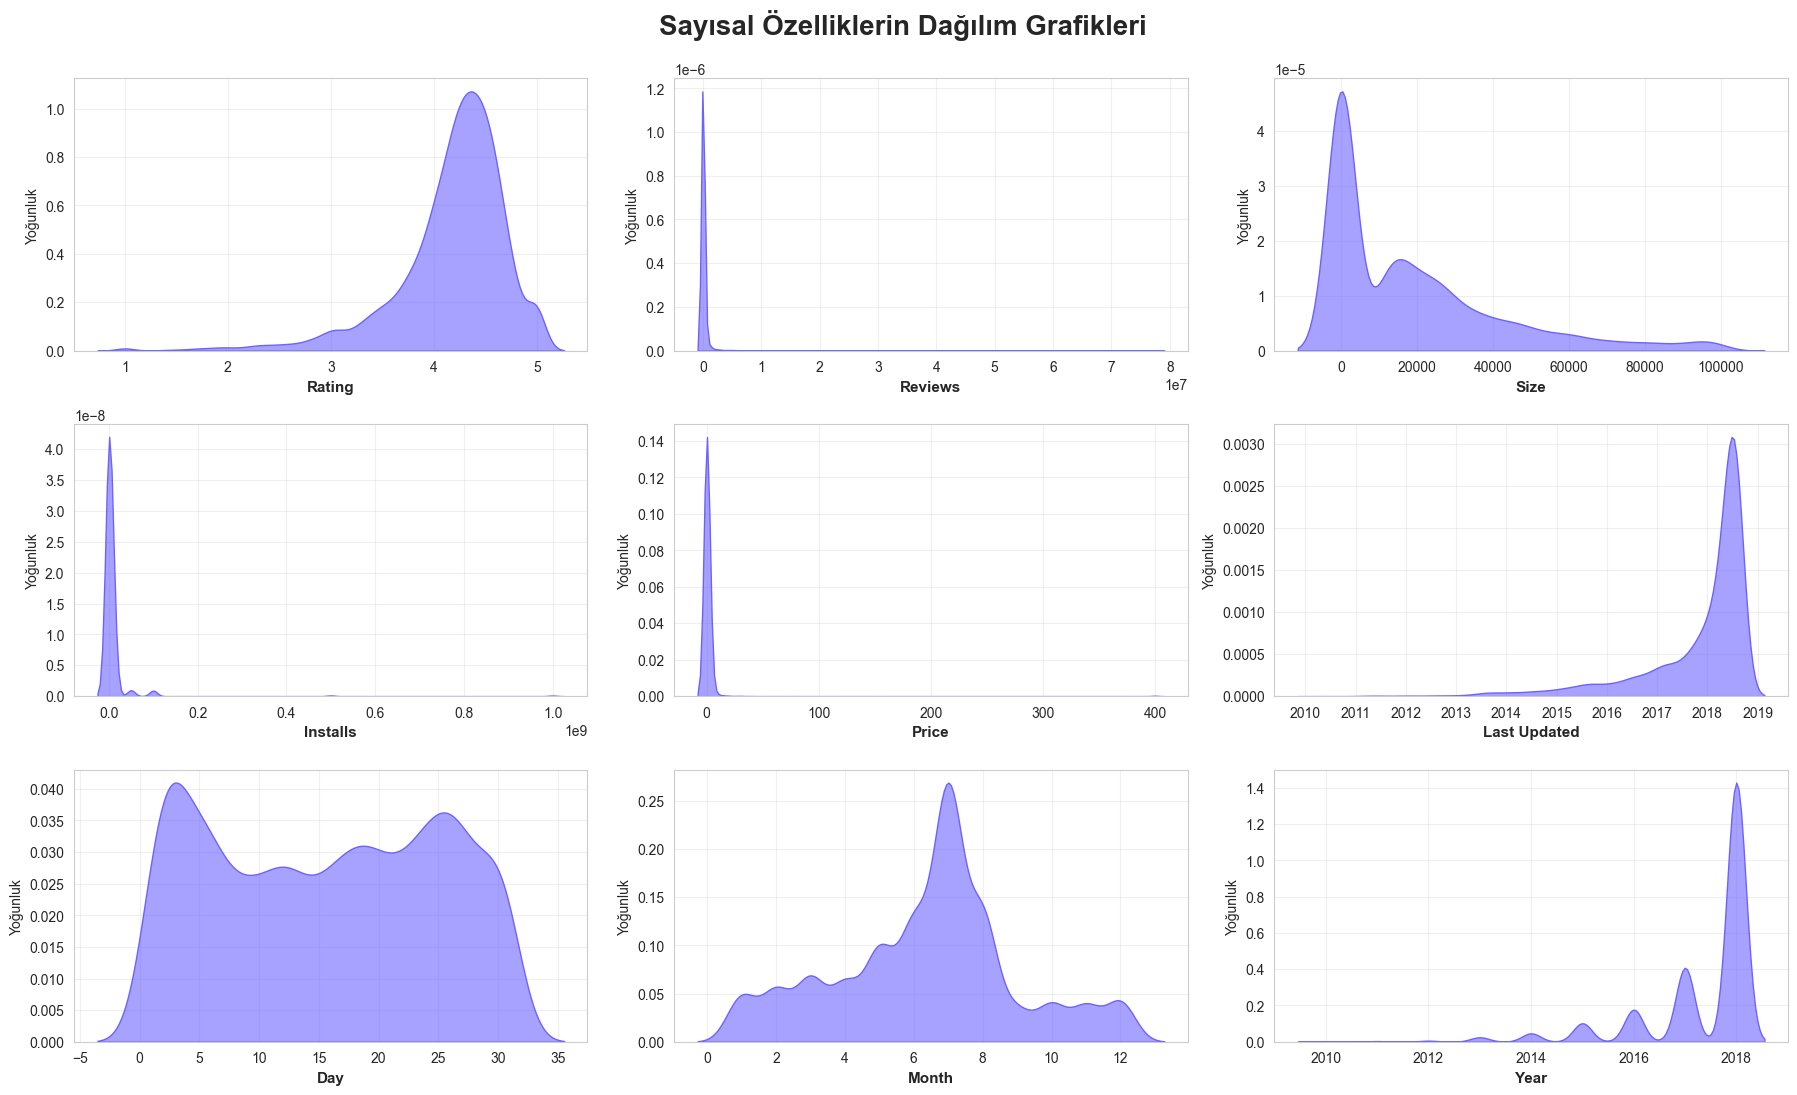

In [45]:
# Sayısal özellikler için KDE (Kernel Density Estimation) grafikleri
# KDE: Histogram'ın pürüzsüz versiyonu - veri dağılımını gösterir

plt.figure(figsize=(18, 14))
plt.suptitle('Sayısal Özelliklerin Dağılım Grafikleri', 
             fontsize=20, fontweight='bold', y=0.995)

for i in range(0, len(numeric_features)):
    plt.subplot(4, 3, i+1)
    
    # KDE grafiği çizme
    sns.kdeplot(x=df_clean[numeric_features[i]], fill=True, color='#6C63FF', alpha=0.6)
    
    plt.xlabel(numeric_features[i], fontsize=11, fontweight='bold')
    plt.ylabel('Yoğunluk', fontsize=10)
    plt.grid(alpha=0.3)
    
plt.tight_layout()
plt.show()

> **📊 Grafik Yorumlama İpuçları:**
> - **Sola çarpık**: Çoğu değer küçük, birkaç değer çok büyük (örn: Reviews)
> - **Sağa çarpık**: Çoğu değer büyük, birkaç değer çok küçük
> - **Normal dağılım**: Orta değerler etrafında simetrik yığılma (çan eğrisi)
> - **Çok tepeli**: Birden fazla yoğunluk noktası - farklı gruplar olabilir

## 📊 **Kategorik Değişkenlerin Frekans Grafikleri**

Kategorik değişkenler için **count plot** (sayma grafiği) kullanırız.

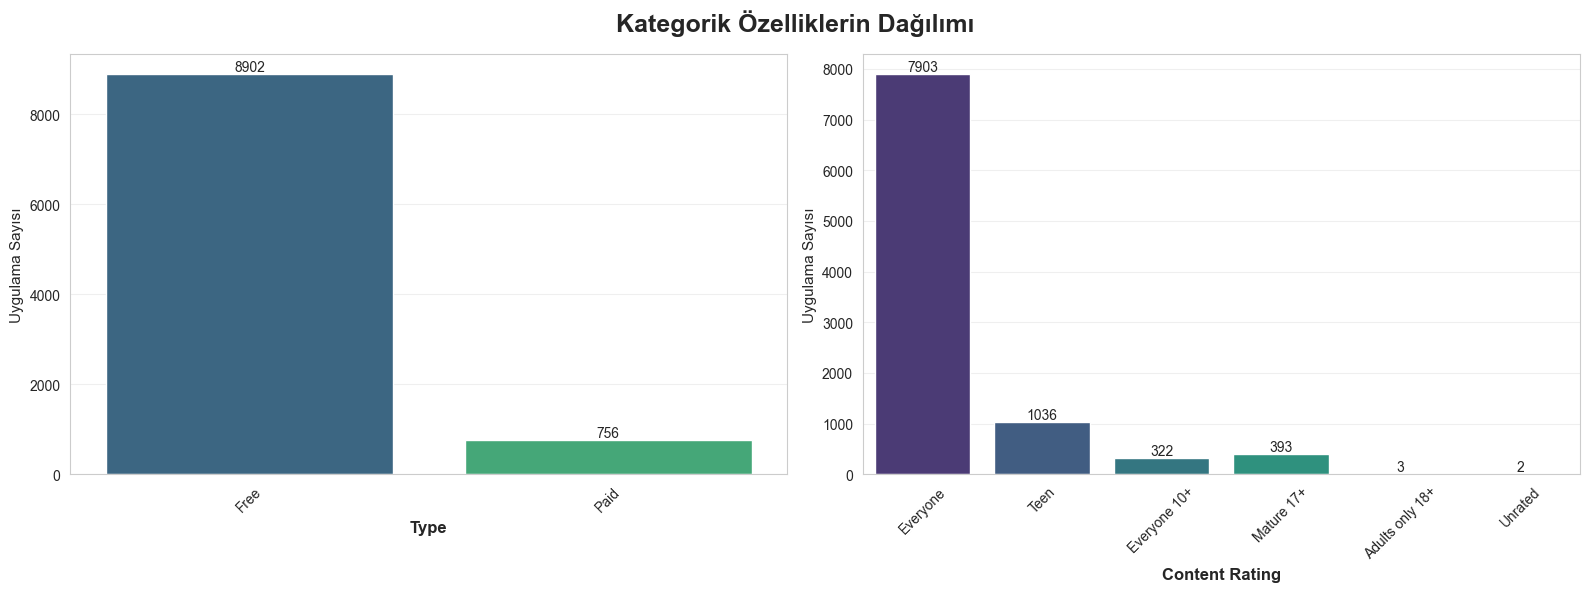

In [46]:
# İki önemli kategorik değişken için count plot
# Count plot: Her kategoride kaç veri olduğunu gösterir

plt.figure(figsize=(16, 6))
plt.suptitle('Kategorik Özelliklerin Dağılımı', 
             fontsize=18, fontweight='bold')

category = ['Type', 'Content Rating']

for i in range(0, len(category)):
    plt.subplot(1, 2, i+1)
    
    # Count plot oluşturma
    sns.countplot(data=df_clean, x=category[i], 
                  palette='viridis', hue=category[i], legend=False)
    
    plt.xlabel(category[i], fontsize=12, fontweight='bold')
    plt.ylabel('Uygulama Sayısı', fontsize=11)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # Bar'ların üzerine sayı yazma
    ax = plt.gca()
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=10)
    
plt.tight_layout() 
plt.show()

> **💡 YBS Analiz Notları:**
> - **Type**: Ücretsiz (Free) vs Ücretli (Paid) uygulama oranı
> - **Content Rating**: Yaş grubu hedeflemesi (Everyone, Teen, Mature vb.)
>
> Bu dağılımlar, **hedef kitle analizi** ve **pazar segmentasyonu** için kullanılır.

In [48]:
# Temiz veri setinin son hali
df_clean.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


## 8️⃣ **İş Zekası Analizleri - Kategori Performans Analizi**

Artık **iş sorularına** cevap bulma zamanı! Hangi kategorilerdeki uygulamalar daha başarılı?

## 📱 **En Popüler Uygulama Kategorileri**

Önce hangi kategorilerde daha çok uygulama olduğunu görelim.

In [50]:
# value_counts(): Her kategoride kaç uygulama olduğunu sayar
category_counts = df_clean['Category'].value_counts()

print("📱 Kategori Bazında Uygulama Sayıları (Top 15):")
print("=" * 70)
for i, (category, count) in enumerate(category_counts.head(15).items(), 1):
    percentage = (count / len(df_clean)) * 100
    print(f"   {i:2}. {category:25} {count:4} uygulama (%{percentage:5.2f})")

📱 Kategori Bazında Uygulama Sayıları (Top 15):
    1. FAMILY                    1832 uygulama (%18.97)
    2. GAME                       959 uygulama (% 9.93)
    3. TOOLS                      827 uygulama (% 8.56)
    4. BUSINESS                   420 uygulama (% 4.35)
    5. MEDICAL                    395 uygulama (% 4.09)
    6. PERSONALIZATION            376 uygulama (% 3.89)
    7. PRODUCTIVITY               374 uygulama (% 3.87)
    8. LIFESTYLE                  369 uygulama (% 3.82)
    9. FINANCE                    345 uygulama (% 3.57)
   10. SPORTS                     325 uygulama (% 3.36)
   11. COMMUNICATION              315 uygulama (% 3.26)
   12. HEALTH_AND_FITNESS         288 uygulama (% 2.98)
   13. PHOTOGRAPHY                281 uygulama (% 2.91)
   14. NEWS_AND_MAGAZINES         254 uygulama (% 2.63)
   15. SOCIAL                     239 uygulama (% 2.47)


## 🏆 **Kategori Bazında Toplam Yüklenme Analizi**

Hangi kategoriler en çok yüklenmeye sahip? Bu, **pazar büyüklüğünü** gösterir.

In [51]:
# groupby() + sum(): Kategori bazında toplam yükleme sayısını hesaplama
# sort_values(): En yüksekten en düşüğe sıralama

df_cat_installs = df_clean.groupby(['Category'])['Installs'].sum().sort_values(ascending=False).reset_index()

print("🏆 Kategori Bazında Toplam Yüklenme:")
print(df_cat_installs.head(15))

🏆 Kategori Bazında Toplam Yüklenme:
               Category     Installs
0                  GAME  13878924415
1         COMMUNICATION  11038276251
2                 TOOLS   8001771915
3          PRODUCTIVITY   5793091369
4                SOCIAL   5487867902
5           PHOTOGRAPHY   4649147655
6                FAMILY   4427941505
7         VIDEO_PLAYERS   3926902720
8      TRAVEL_AND_LOCAL   2894887146
9    NEWS_AND_MAGAZINES   2369217760
10        ENTERTAINMENT   2113660000
11  BOOKS_AND_REFERENCE   1665969576
12      PERSONALIZATION   1532494782
13             SHOPPING   1400348785
14   HEALTH_AND_FITNESS   1144022512


## 🔄 **Milyar Cinsine Dönüştürme**

Sayılar çok büyük - grafikte göstermek için milyar cinsine çevirelim.

In [52]:
# Yüklenme sayılarını milyar (billion) cinsine çevirme
# Daha okunabilir gösterim için
df_cat_installs['Installs'] = df_cat_installs['Installs'] / 1_000_000_000

print("📊 Milyar Cinsinden Yüklenme Sayıları:")
print(df_cat_installs.head(15))

📊 Milyar Cinsinden Yüklenme Sayıları:
               Category   Installs
0                  GAME  13.878924
1         COMMUNICATION  11.038276
2                 TOOLS   8.001772
3          PRODUCTIVITY   5.793091
4                SOCIAL   5.487868
5           PHOTOGRAPHY   4.649148
6                FAMILY   4.427942
7         VIDEO_PLAYERS   3.926903
8      TRAVEL_AND_LOCAL   2.894887
9    NEWS_AND_MAGAZINES   2.369218
10        ENTERTAINMENT   2.113660
11  BOOKS_AND_REFERENCE   1.665970
12      PERSONALIZATION   1.532495
13             SHOPPING   1.400349
14   HEALTH_AND_FITNESS   1.144023


## 📊 **Top 10 Kategori Görselleştirmesi**

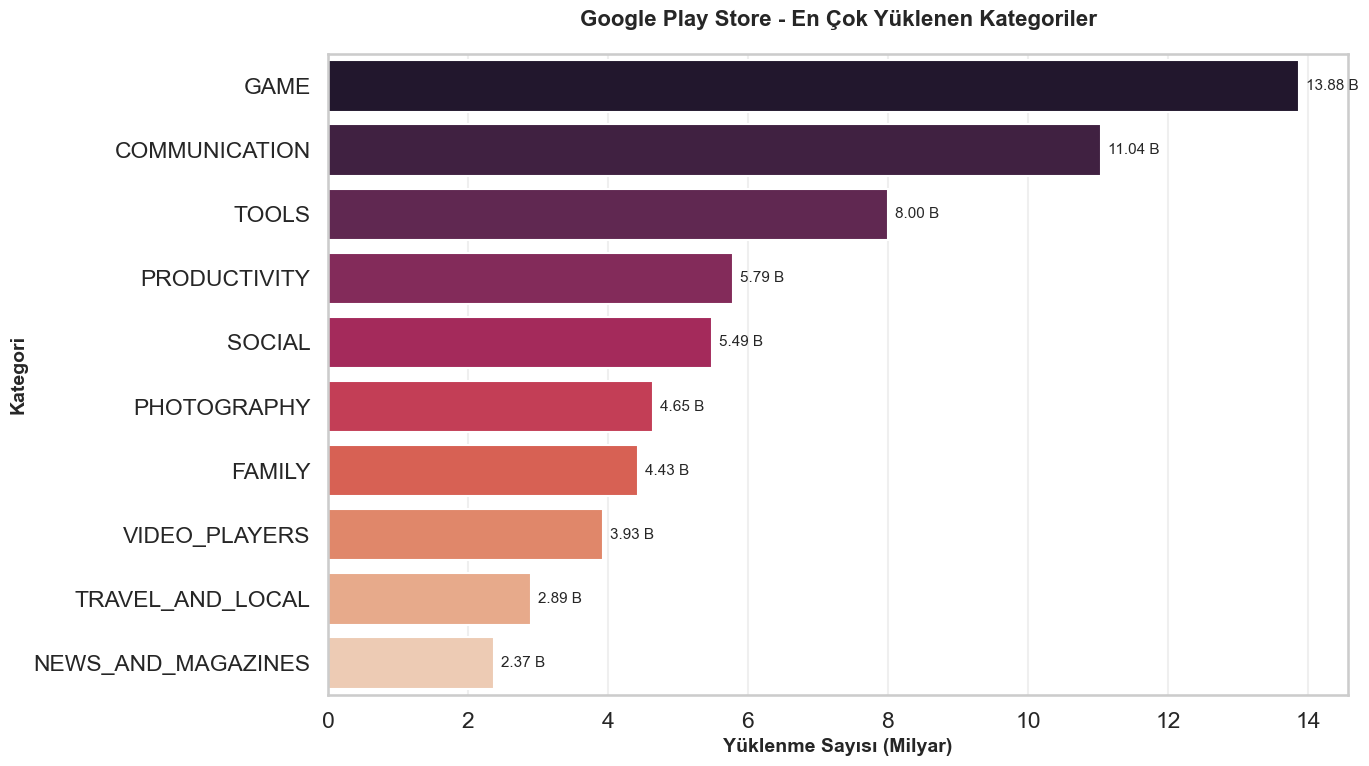

In [53]:
# En popüler 10 kategoriyi görselleştirme
df_top10 = df_cat_installs.head(10)

plt.figure(figsize=(14, 8))
sns.set_context("talk")

# Horizontal bar plot (yatay çubuk grafik)
ax = sns.barplot(x='Installs', y='Category', data=df_top10, 
                 palette='rocket', hue='Category', legend=False)

ax.set_xlabel('Yüklenme Sayısı (Milyar)', fontsize=14, fontweight='bold')
ax.set_ylabel('Kategori', fontsize=14, fontweight='bold')
ax.set_title('Google Play Store - En Çok Yüklenen Kategoriler', 
             fontsize=16, fontweight='bold', pad=20)

# Bar'ların yanına değer yazma
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f B', fontsize=11, padding=5)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

> **💼 İş İçgörüleri:**
> - **GAME** kategorisi açık ara lider → Oyun sektörü dev pazar
> - **COMMUNICATION** ikinci sırada → İletişim uygulamaları kritik
> - **PRODUCTIVITY** ve **SOCIAL** yüksek → İş ve sosyal uygulamalar talep görüyor
>
> **🎯 Strateji Önerisi:**  
> Yeni bir uygulama geliştiriyorsanız, bu kategoriler yüksek kullanıcı tabanına sahip ama rekabet de yoğun.

## 9️⃣ **Kategori Bazında Top 5 Uygulamalar**

Her bir popüler kategoride **hangi uygulamalar** lider? Rakip analizi için bu bilgi kritik.

## 🎯 Analiz Hazırlığı

Kategori ve uygulama bazında yüklenme sayılarını gruplandırıyoruz.

In [54]:
# Kategori ve Uygulama bazında toplam yüklenme
df_app_category = df_clean.groupby(['Category', 'App'])['Installs'].sum().reset_index()
df_app_category = df_app_category.sort_values('Installs', ascending=False)

print("📊 Kategori ve Uygulama Bazında Yüklenme Verileri:")
print(df_app_category.head(15))

📊 Kategori ve Uygulama Bazında Yüklenme Verileri:
                 Category                                       App  \
9342     TRAVEL_AND_LOCAL                 Maps - Navigate & Explore   
1534        ENTERTAINMENT                         Google Play Games   
9496        VIDEO_PLAYERS                   Google Play Movies & TV   
6388   NEWS_AND_MAGAZINES                               Google News   
1145        COMMUNICATION             Skype - free IM & video calls   
1181        COMMUNICATION                        WhatsApp Messenger   
9311     TRAVEL_AND_LOCAL                        Google Street View   
7080          PHOTOGRAPHY                             Google Photos   
1099        COMMUNICATION  Messenger – Text and Video Chat for Free   
7883               SOCIAL                                  Facebook   
341   BOOKS_AND_REFERENCE                         Google Play Books   
4773                 GAME                            Subway Surfers   
1058        COMMUNICATION  

## 🏆 **Top 5 Uygulamalar - Popüler Kategorilerde**

5 ana kategoride en çok yüklenen 5 uygulamayı görselleştirelim.

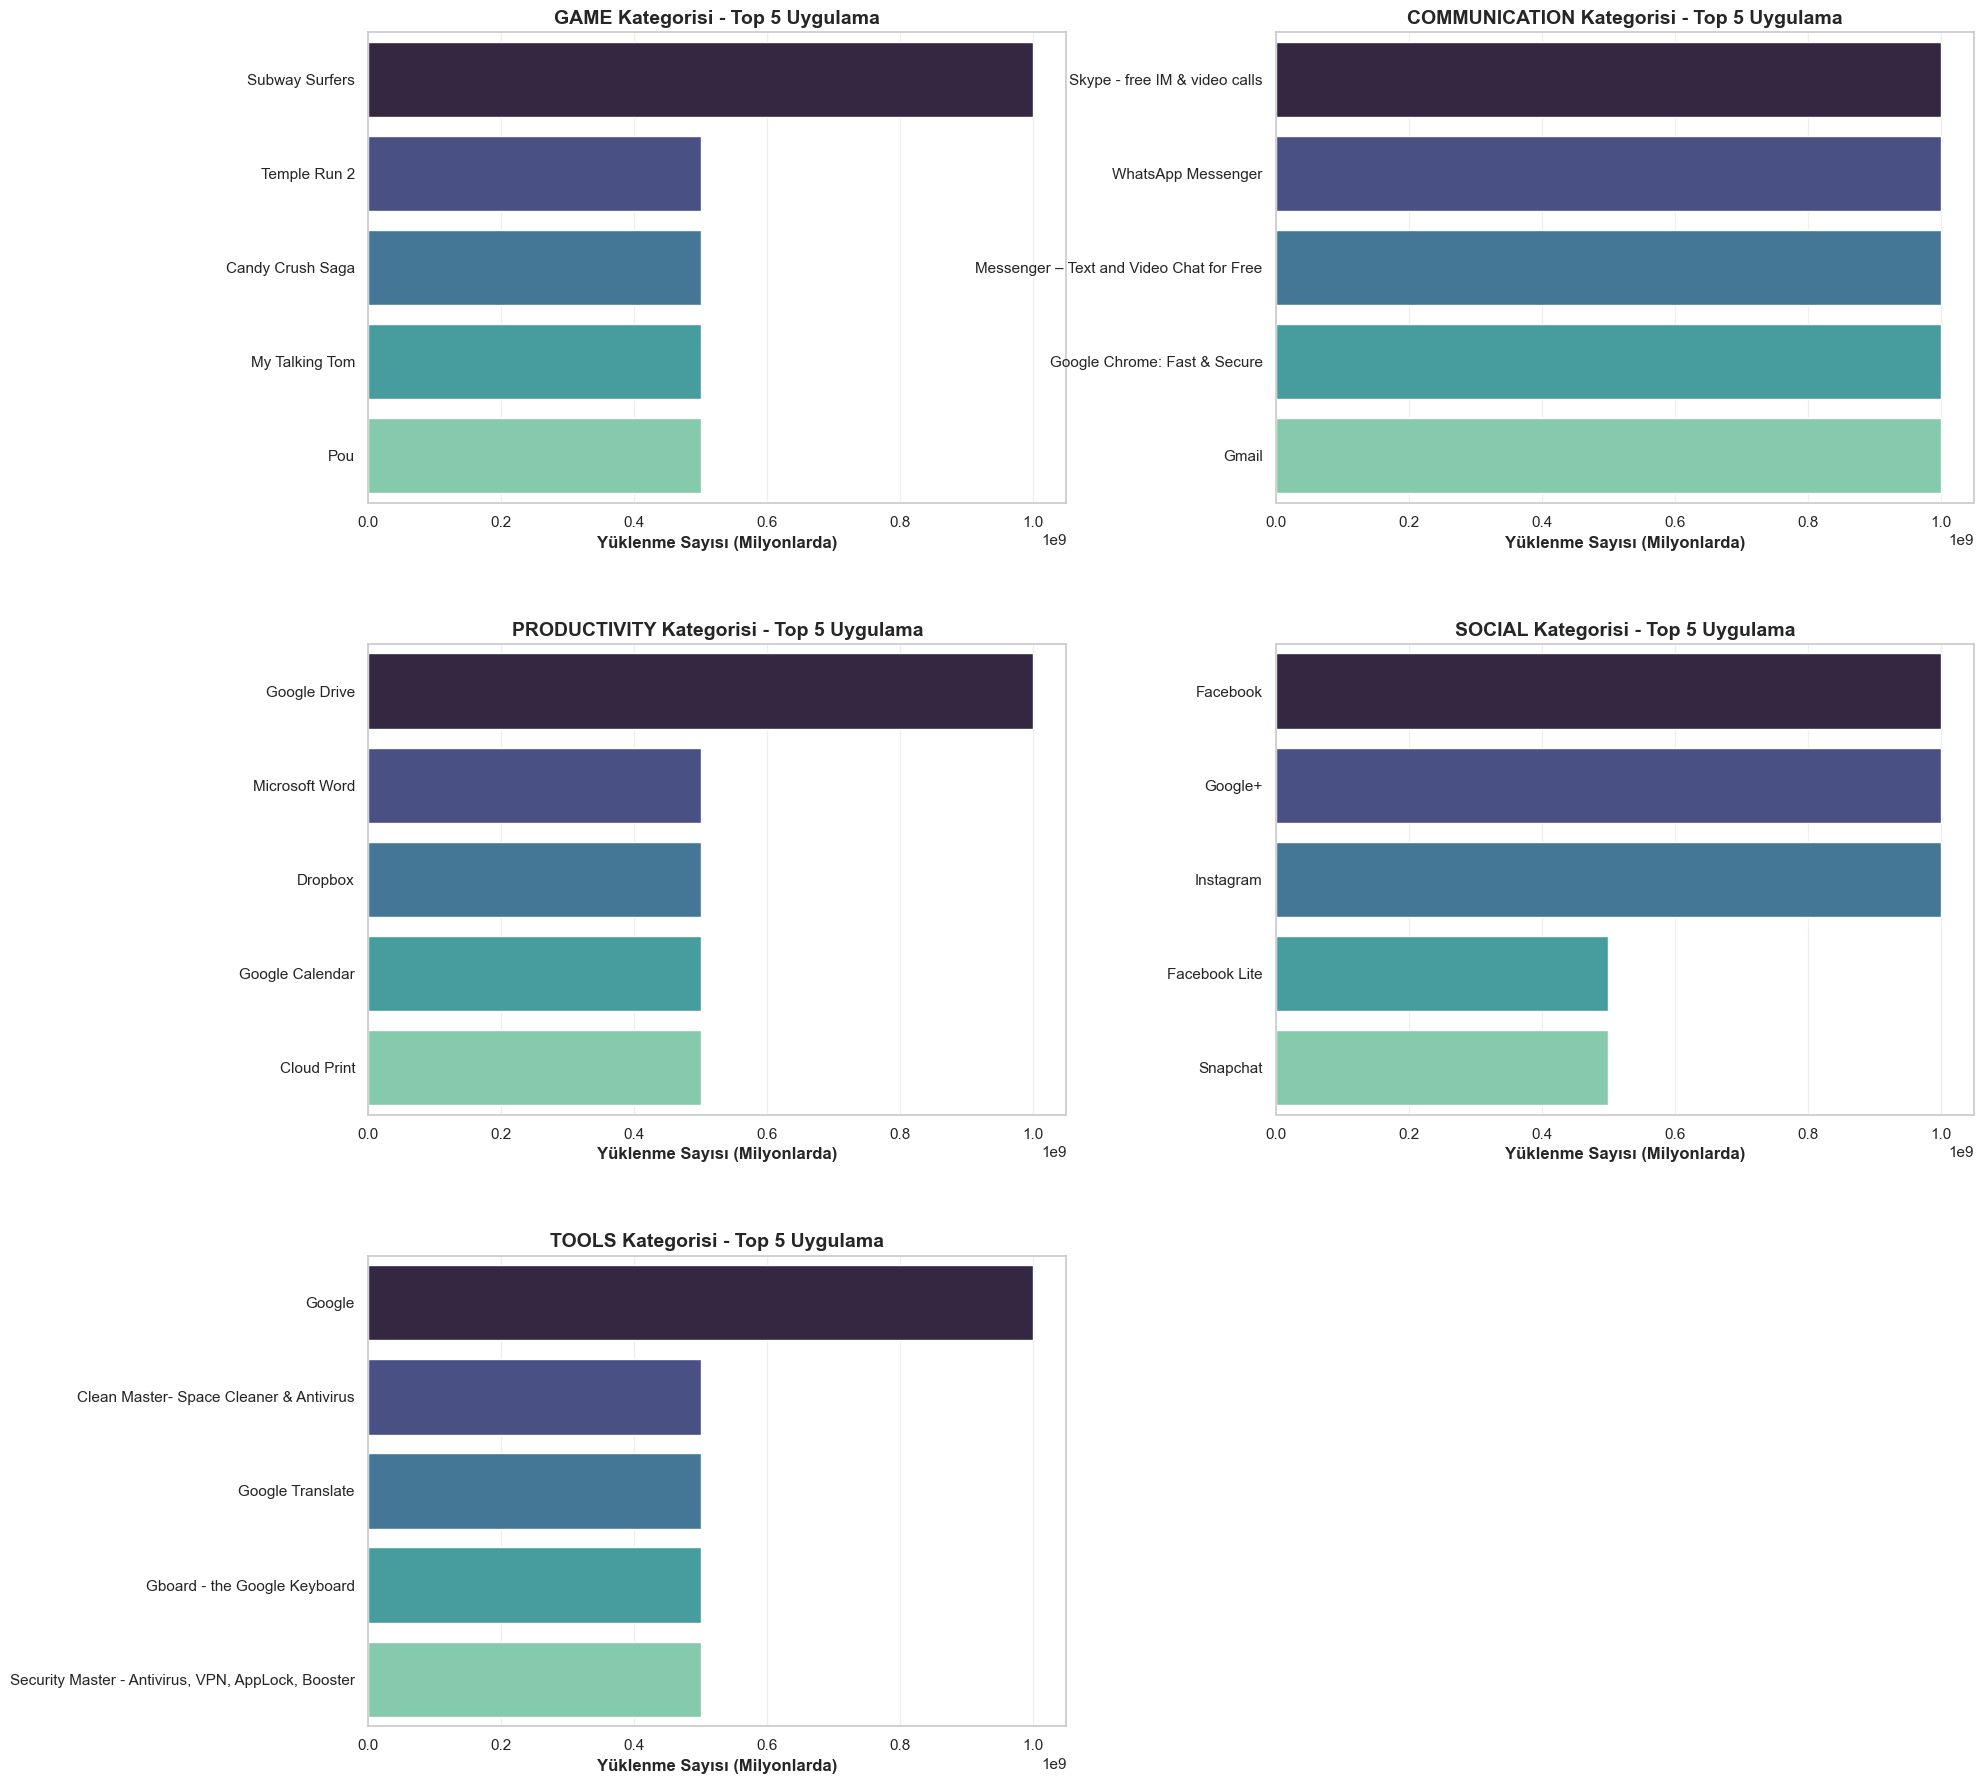

In [55]:
# Analiz edilecek kategoriler
apps = ['GAME', 'COMMUNICATION', 'PRODUCTIVITY', 'SOCIAL', 'TOOLS']

# Grafik boyutunu ve stilini ayarlama
sns.set_context("notebook")
plt.figure(figsize=(20, 18))

for i, app in enumerate(apps):
    # Her kategori için filtreleme
    df_category = df_app_category[df_app_category.Category == app]
    
    # Her kategoriden top 5 uygulama seçme
    df_top_5 = df_category.head(5)
    
    # Alt grafik oluşturma
    plt.subplot(3, 2, i+1)
    
    # Horizontal bar plot
    sns.barplot(data=df_top_5, x='Installs', y='App', 
                palette='mako', hue='App', legend=False)
    
    plt.xlabel('Yüklenme Sayısı (Milyonlarda)', fontsize=12, fontweight='bold')
    plt.ylabel('')
    plt.title(f'{app} Kategorisi - Top 5 Uygulama', 
              fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

> **🔍 Rakip Analizi İçgörüleri:**
> - **GAME**: Benzersiz oyunlar farklı kullanıcı segmentlerine hitap ediyor
> - **COMMUNICATION**: WhatsApp, Skype gibi global uygulamalar dominant
> - **PRODUCTIVITY**: Google ürünleri (Gmail, Drive) lider konumda
> - **SOCIAL**: Facebook, Instagram gibi dev sosyal platformlar
> - **TOOLS**: System utility ve optimize edici uygulamalar popüler
>
> **💼 YBS Uygulaması:**  
> Bu tür analizler, **rekabet analizi raporları** ve **pazar pozisyonlama stratejileri** için kullanılır.

## 🔟 **Rating (Derecelendirme) Analizi**

5 üzerinden 5 puan alan uygulamalar hangileri? Mükemmel kullanıcı deneyimi sağlayan uygulamaları inceleyelim.

## ⭐ **5 Yıldızlı Uygulamaların Tespiti**

In [56]:
# Kategori, Yüklenme ve Uygulama bazında rating'leri gruplama
rating_df = df_clean.groupby(['Category', 'Installs', 'App'])['Rating'].sum().sort_values(ascending=False).reset_index()

# Rating'i tam 5.0 olan uygulamaları filtreleme
top_rated_apps = rating_df[rating_df.Rating == 5.0]

print(f"⭐ 5 Yıldızlı Uygulama Sayısı: {top_rated_apps.shape[0]}")
print(f"   Toplam uygulama içindeki oranı: %{(top_rated_apps.shape[0] / len(df_clean)) * 100:.2f}")

⭐ 5 Yıldızlı Uygulama Sayısı: 271
   Toplam uygulama içindeki oranı: %2.81


In [57]:
# 5 yıldızlı uygulamaların detayları
print("⭐ 5 Yıldız Alan Uygulamalar (İlk 20):")
print("=" * 80)
top_rated_apps.head(20)

⭐ 5 Yıldız Alan Uygulamalar (İlk 20):


,Category,Installs,App,Rating
0,FAMILY,10,DN Employee,5.0
1,FAMILY,10,Chronolink DX,5.0
2,MEDICAL,500,FHR 5-Tier 2.0,5.0
3,HEALTH_AND_FITNESS,10,CB Fit,5.0
4,MEDICAL,100,Zen Leaf,5.0
5,MEDICAL,100,Sway Medical,5.0
6,MEDICAL,100,Super Hearing Secret Voices Recorder PRO,5.0
7,MEDICAL,100,Kimbrough AH,5.0
8,COMMUNICATION,100,chat dz,5.0
9,MEDICAL,100,Dermatology Atlas (Colored & Illustrative),5.0


> **💡 Dikkat:**  
> 5 yıldıza sahip olmak her zaman "en iyi" demek değildir. Bu uygulamaların bazılarının çok az sayıda değerlendirmesi olabilir!
>
> **🎯 YBS Analiz Yaklaşımı:**  
> Kaliteli rating analizi için hem **puan** hem de **inceleme sayısını** birlikte değerlendirmelisiniz:
> ```
> Kalite Skoru = Rating × log(Reviews + 1)
> ```

In [58]:
# Genel veri yapısı kontrolü
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9659 non-null   object        
 1   Category        9659 non-null   object        
 2   Rating          8196 non-null   float64       
 3   Reviews         9659 non-null   int64         
 4   Size            8432 non-null   float64       
 5   Installs        9659 non-null   int64         
 6   Type            9658 non-null   object        
 7   Price           9659 non-null   float64       
 8   Content Rating  9659 non-null   object        
 9   Genres          9659 non-null   object        
 10  Last Updated    9659 non-null   datetime64[ns]
 11  Current Ver     9651 non-null   object        
 12  Android Ver     9657 non-null   object        
 13  Day             9659 non-null   int32         
 14  Month           9659 non-null   int32         
 15  Year    

## 1️⃣1️⃣ **İleri Veri Temizleme - Android Version**

**Android Ver** sütunu, uygulamanın desteklediği minimum Android versiyonunu gösterir. Ancak bu sütun da temizlik gerektiriyor.

## 🔍 **Android Ver Sütununun Mevcut Durumu**

In [59]:
# Android Version değerlerini inceleyelim
print("📱 Android Ver sütunu örnek değerler:")
print(df_clean['Android Ver'].head(20))

📱 Android Ver sütunu örnek değerler:
0     4.0.3 and up
1     4.0.3 and up
2     4.0.3 and up
3       4.2 and up
4       4.4 and up
5       2.3 and up
6     4.0.3 and up
7       4.2 and up
8       3.0 and up
9     4.0.3 and up
10      4.1 and up
11      4.0 and up
12      4.1 and up
13      4.4 and up
14      2.3 and up
15      4.2 and up
16      4.1 and up
17      2.3 and up
18    4.0.3 and up
19      4.1 and up
Name: Android Ver, dtype: object


## 🧹 **Adım 1: "and up" İfadesini Silme**

Sürüm numaralarında "4.1 and up" gibi ifadeler var. Sadece versiyon numarasını istiyoruz.

In [60]:
# "and up" ifadesini boş string ile değiştirme
# regex=True: Regular expression (düzenli ifade) kullanımını aktif eder
df_clean['Android Ver'] = df_clean['Android Ver'].replace('and up', '', regex=True)

print("✅ 'and up' ifadesi silindi")
print("\n🔍 Güncellenmiş değerler:")
print(df_clean['Android Ver'].head(20))

✅ 'and up' ifadesi silindi

🔍 Güncellenmiş değerler:
0     4.0.3 
1     4.0.3 
2     4.0.3 
3       4.2 
4       4.4 
5       2.3 
6     4.0.3 
7       4.2 
8       3.0 
9     4.0.3 
10      4.1 
11      4.0 
12      4.1 
13      4.4 
14      2.3 
15      4.2 
16      4.1 
17      2.3 
18    4.0.3 
19      4.1 
Name: Android Ver, dtype: object


In [61]:
# Değer dağılımına bakalım
print("📊 Android Version değer dağılımı (Top 15):")
print("=" * 60)
df_clean['Android Ver'].value_counts().head(15)

📊 Android Version değer dağılımı (Top 15):


Android Ver
4.1                   2202
4.0.3                 1395
4.0                   1285
Varies with device     990
4.4                    818
2.3                    616
5.0                    512
4.2                    372
2.3.3                  273
2.2                    239
3.0                    231
4.3                    221
2.1                    133
1.6                    116
6.0                     54
Name: count, dtype: int64

## 🧹 **Adım 2: "Varies with device" ve Diğer Özel Değerleri Temizleme**

Bazı uygulamalar cihaza göre değişen versiyon gereksinimi belirtiyor. Bu standardize edilemez.

In [62]:
# Birden fazla temizlik işlemini zincirleme
# Method chaining: Birden fazla metodu peş peşe çağırma
df_clean['Android Ver'] = (df_clean['Android Ver']
                            .replace('Varies with device', '', regex=True)
                            .replace('W', '', regex=True)  # "W" karakterini sil
                            .replace('', np.nan))  # Boş string'leri NaN yap

print("✅ Özel değerler temizlendi, boş değerler NaN'a çevrildi")
print(f"\n📉 NaN sayısı: {df_clean['Android Ver'].isnull().sum()}")

✅ Özel değerler temizlendi, boş değerler NaN'a çevrildi

📉 NaN sayısı: 992


In [63]:
# Güncellenmiş değer dağılımı
print("📊 Temizlenmiş Android Version dağılımı:")
print("=" * 60)
df_clean['Android Ver'].value_counts().head(20)

📊 Temizlenmiş Android Version dağılımı:


Android Ver
4.1       2202
4.0.3     1395
4.0       1285
4.4        829
2.3        616
5.0        512
4.2        372
2.3.3      273
2.2        239
3.0        231
4.3        221
2.1        133
1.6        116
6.0         54
7.0         42
3.2         36
2.0         32
5.1         22
1.5         20
3.1         10
Name: count, dtype: int64

## 🔍 **Adım 3: Aralık İçeren Değerleri Bulma**

Bazı satırlarda "4.0 - 7.0" gibi aralık değerleri olabilir. Bunları tespit edip silelim.

In [64]:
# str.contains('-'): String içinde '-' (tire) karakteri var mı kontrol eder
# Tire varsa, bu bir aralık değeri demektir (örn: "4.0 - 7.0")

# Önce kaç tane aralık değeri var görelim
range_values = df_clean.loc[df_clean['Android Ver'].str.contains('-', na=False) == True]
print(f"⚠️ Aralık içeren değer sayısı: {len(range_values)}")

if len(range_values) > 0:
    print("\n🔍 Aralık içeren örnekler:")
    print(range_values[['App', 'Android Ver']].head(10))

⚠️ Aralık içeren değer sayısı: 9

🔍 Aralık içeren örnekler:
                                 App    Android Ver
350           Web Browser & Explorer  4.0.3 - 7.1.1
352                       Browser 4G  4.0.3 - 7.1.1
1572                 ZenUI Safeguard    7.0 - 7.1.1
2841   Photo Collage - Layout Editor      5.0 - 8.0
3474                 ASUS Quick Memo      5.0 - 8.0
4151             Google Now Launcher    4.1 - 7.1.1
7571            My Style CM 13 Theme      5.0 - 6.0
9310                       EF Jumper    2.2 - 7.1.1
10094             EY Catalyst Reader    5.0 - 7.1.1


## 🗑️ **Aralık İçeren Satırları Filtreleme**

Bu satırları veri setinden çıkarıyoruz çünkü tek bir versiyon numarası istemiyoruz.

In [65]:
# Boolean indexing: Sadece tire içermeyen satırları koruma
# == False: Tire içermeyenler
initial_count = len(df_clean)

df_clean = df_clean.loc[df_clean['Android Ver'].str.contains('-', na=False) == False]

final_count = len(df_clean)

print("✅ Aralık içeren satırlar filtrelendi")
print(f"   Önceki satır sayısı: {initial_count:,}")
print(f"   Yeni satır sayısı: {final_count:,}")
print(f"   Filtrelenen satır: {initial_count - final_count:,}")

✅ Aralık içeren satırlar filtrelendi
   Önceki satır sayısı: 9,659
   Yeni satır sayısı: 9,650
   Filtrelenen satır: 9


In [66]:
# Final Android Version değer dağılımı
print("📊 Final Android Version Dağılımı (Top 15):")
print("=" * 60)
df_clean['Android Ver'].value_counts().head(15)

📊 Final Android Version Dağılımı (Top 15):


Android Ver
4.1       2202
4.0.3     1395
4.0       1285
4.4        829
2.3        616
5.0        512
4.2        372
2.3.3      273
2.2        239
3.0        231
4.3        221
2.1        133
1.6        116
6.0         54
7.0         42
Name: count, dtype: int64

In [67]:
# Son veri yapısı
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9650 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9650 non-null   object        
 1   Category        9650 non-null   object        
 2   Rating          8189 non-null   float64       
 3   Reviews         9650 non-null   int64         
 4   Size            8423 non-null   float64       
 5   Installs        9650 non-null   int64         
 6   Type            9649 non-null   object        
 7   Price           9650 non-null   float64       
 8   Content Rating  9650 non-null   object        
 9   Genres          9650 non-null   object        
 10  Last Updated    9650 non-null   datetime64[ns]
 11  Current Ver     9642 non-null   object        
 12  Android Ver     8658 non-null   object        
 13  Day             9650 non-null   int32         
 14  Month           9650 non-null   int32         
 15  Year    

## 1️⃣2️⃣ **Feature Engineering - Target Mean Encoding**

**Encoding**, kategorik (metin) verileri sayısal formata dönüştürme işlemidir. Makine öğrenmesi modelleri sadece sayılarla çalışabilir, bu yüzden encoding kritik bir adımdır.

**Target Mean Encoding**, her kategorinin hedef değişkene göre ortalamasını kullanarak encoding yapar.

## 🎓 **Target Mean Encoding Nedir?**

```mermaid
graph TD
    A[Genres Sütunu<br/>Kategorik] --> B[Her genre için<br/>ortalama Installs hesapla]
    B --> C[Action: 50M<br/>Education: 10M<br/>Sports: 30M]
    C --> D[Kategorik değerleri<br/>bu ortalamalarla değiştir]
    D --> E[Genres Encoded<br/>Sayısal]
    
    style A fill:#FFE5E5,stroke:#FF6B6B,stroke-width:2px
    style E fill:#E5FFE5,stroke:#4DFF88,stroke-width:2px
    style B fill:#E5F5FF,stroke:#4D94FF,stroke-width:2px
    style C fill:#FFF4E5,stroke:#FFB84D,stroke-width:2px
```

**Avantajları:**
- Kategorilerin hedef değişkenle ilişkisini korur
- Yüksek kardinalite (çok fazla kategori) problemini çözer
- Model performansını artırabilir

**Dezavantajları:**
- Overfitting riski (train-test split sonrası dikkatli olunmalı)
- Nadir kategorilerde güvenilmez olabilir

## 🎯 **Örnek: Genres Sütunu Encoding**

**Genres** sütunu, uygulamanın türünü belirtir (Action, Education, Sports vb.). Bu sütunu **Installs** (hedef değişken) ortalamasına göre encode edeceğiz.

### 1️⃣ Her Genre için Ortalama Installs Hesaplama

In [68]:
# groupby("Genres"): Genre'lere göre gruplandır
# ["Installs"].mean(): Her grup için ortalama yüklenme sayısını hesapla
# / 1_000_000: Milyon cinsine çevir (daha okunabilir)

mean_genres_installs = df_clean.groupby("Genres")["Installs"].mean() / 1_000_000

print("📊 Genre Bazında Ortalama Yüklenme Sayıları (Milyon):")
print("=" * 70)
print(mean_genres_installs.sort_values(ascending=False).head(20))

📊 Genre Bazında Ortalama Yüklenme Sayıları (Milyon):
Genres
Communication                     35.218135
Video Players & Editors           24.178412
Social                            22.961790
Adventure;Action & Adventure      21.230000
Arcade                            20.519831
Casual                            18.502004
Puzzle;Action & Adventure         18.366667
Educational;Action & Adventure    17.016667
Photography                       16.568384
Productivity                      15.504266
Racing                            15.387333
Travel & Local                    13.278840
Casual;Action & Adventure         11.923154
Action                            11.648961
Lifestyle;Pretend Play            10.000000
Adventure;Education               10.000000
Casual;Music & Video              10.000000
Tools;Education                   10.000000
Role Playing;Brain Games          10.000000
Strategy                           9.623027
Name: Installs, dtype: float64


> **💡 Yorumlama:**  
> - **Yüksek ortalama**: O genre'deki uygulamalar genellikle çok yükleniyor
> - **Düşük ortalama**: Niş bir alan, daha az kullanıcı tabanı
>
> Bu bilgi, **yeni uygulama geliştirirken genre seçimi** için değerlidir.

### 2️⃣ Dictionary'ye Dönüştürme

`map()` fonksiyonu için dictionary formatı gerekiyor.

In [69]:
# Series'i dictionary'ye çevirme
# to_dict(): Series'teki index-value çiftlerini dictionary'ye dönüştürür
# Örnek: {"Action": 45.3, "Education": 12.7, ...}

mean_genres_installs = mean_genres_installs.to_dict()

print("✅ Dictionary formatına dönüştürüldü")
print(f"   Toplam {len(mean_genres_installs)} genre için ortalama hesaplandı")
print("\n🔍 İlk 5 genre:")
for i, (genre, avg) in enumerate(list(mean_genres_installs.items())[:5], 1):
    print(f"   {i}. {genre}: {avg:.2f} M")

✅ Dictionary formatına dönüştürüldü
   Toplam 118 genre için ortalama hesaplandı

🔍 İlk 5 genre:
   1. Action: 11.65 M
   2. Action;Action & Adventure: 4.42 M
   3. Adventure: 4.06 M
   4. Adventure;Action & Adventure: 21.23 M
   5. Adventure;Brain Games: 0.10 M


### 3️⃣ Map İşlemi ile Encoding

In [70]:
# map() fonksiyonu: Bir sütundaki her değeri başka bir değerle eşleştirir
# Genre ismini, o genre'nin ortalama yüklenme sayısı ile değiştirir

df_clean["Genres Encoded"] = df_clean["Genres"].map(mean_genres_installs)

print("✅ Target Mean Encoding tamamlandı")
print("   Yeni sütun: 'Genres Encoded'")

print("\n📊 Karşılaştırmalı Görünüm:")
print("=" * 80)
comparison = df_clean[["App", "Genres", "Genres Encoded", "Installs"]].head(15)
print(comparison)

✅ Target Mean Encoding tamamlandı
   Yeni sütun: 'Genres Encoded'

📊 Karşılaştırmalı Görünüm:
                                                  App  \
0      Photo Editor & Candy Camera & Grid & ScrapBook   
1                                 Coloring book moana   
2   U Launcher Lite – FREE Live Cool Themes, Hide ...   
3                               Sketch - Draw & Paint   
4               Pixel Draw - Number Art Coloring Book   
5                          Paper flowers instructions   
6             Smoke Effect Photo Maker - Smoke Editor   
7                                    Infinite Painter   
8                                Garden Coloring Book   
9                       Kids Paint Free - Drawing Fun   
10                            Text on Photo - Fonteee   
11            Name Art Photo Editor - Focus n Filters   
12                     Tattoo Name On My Photo Editor   
13                              Mandala Coloring Book   
14    3D Color Pixel by Number - Sandbox Art Colori

> **🎓 YBS Öğrencilerine Not:**  
> ```python
> Orijinal: "Action"  →  Encoded: 45.3
> Orijinal: "Education"  →  Encoded: 12.7
> ```
> Artık Genre bilgisi sayısal bir değer haline geldi ve makine öğrenmesi modellerinde kullanılabilir!

## 📊 **Final Veri Seti**

In [72]:
# Temizlenmiş ve feature engineering uygulanmış final veri seti
df_clean.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year,Genres Encoded
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3,7,1,2018,1.974177
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3,15,1,2018,0.500000
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3,1,8,2018,1.974177
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2,8,6,2018,1.974177
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4,20,6,2018,0.285000


In [73]:
# Tüm sütunlar ve veri tipleri
print("📋 Final Veri Seti Yapısı:")
print("=" * 80)
df_clean.info()

📋 Final Veri Seti Yapısı:
<class 'pandas.core.frame.DataFrame'>
Index: 9650 entries, 0 to 10840
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9650 non-null   object        
 1   Category        9650 non-null   object        
 2   Rating          8189 non-null   float64       
 3   Reviews         9650 non-null   int64         
 4   Size            8423 non-null   float64       
 5   Installs        9650 non-null   int64         
 6   Type            9649 non-null   object        
 7   Price           9650 non-null   float64       
 8   Content Rating  9650 non-null   object        
 9   Genres          9650 non-null   object        
 10  Last Updated    9650 non-null   datetime64[ns]
 11  Current Ver     9642 non-null   object        
 12  Android Ver     8658 non-null   object        
 13  Day             9650 non-null   int32         
 14  Month           9650 non-null   in

## 🎯 **Özet ve Sonuç**

Bu notebook boyunca, **Google Play Store** veri setini profesyonel bir veri bilimi projesi olarak işledik.

## ✅ Uygulanan Teknikler

### 🧹 **Veri Temizleme**
- ✔️ Hatalı satırları tespit ve silme
- ✔️ Veri tipleri dönüşümü (string → numeric)
- ✔️ Birim standardizasyonu (M, k → KB)
- ✔️ Özel karakter temizleme (+, $, ,)
- ✔️ Eksik değer yönetimi (NaN ataması)
- ✔️ String pattern temizleme (regex)
- ✔️ Duplicate kayıt silme

### 🔧 **Feature Engineering**
- ✔️ Tarih verilerinden özellik çıkarma (Day, Month, Year)
- ✔️ Target Mean Encoding (Genres → Genres Encoded)
- ✔️ Veri tiplerini analiz için optimize etme

### 📊 **Keşifsel Veri Analizi (EDA)**
- ✔️ Sayısal ve kategorik değişken ayrımı
- ✔️ Dağılım grafikleri (KDE plots)
- ✔️ Frekans grafikleri (Count plots)
- ✔️ Kategori performans analizi
- ✔️ Top uygulamalar analizi
- ✔️ Rating ve yüklenme korelasyonu

### 💼 **İş Zekası İçgörüleri**
- ✔️ En popüler kategorileri belirleme
- ✔️ Rakip analizi (kategori bazında top 5)
- ✔️ Pazar büyüklüğü değerlendirmesi
- ✔️ Kullanıcı tercih analizi

## 🎓 YBS Öğrencileri İçin Önemli Çıkarımlar

> **📊 Veri Temizliği = Analiz Kalitesi**  
> Analiz sonuçlarınız ancak veriniz kadar güvenilirdir. Ham veri üzerinde direkt analiz yapmak yanıltıcı sonuçlar verir.

> **🔧 Feature Engineering = Model Başarısı**  
> Mevcut veriden anlamlı özellikler türetmek, model performansını dramatik şekilde artırır.

> **💼 Veri → İçgörü → Strateji**  
> YBS profesyoneli olarak göreviniz sadece analiz yapmak değil, **iş kararlarına dönüştürmektir**.

> **🎯 Araçlar Değişir, Mantık Kalır**  
> Bu notebook'ta öğrendiğiniz mantık, hangi veri seti ve araçla çalışırsanız çalışın geçerlidir.

## 🎉 Tebrikler!

Bu kapsamlı notebook'u tamamladınız! Artık **profesyonel düzeyde veri temizleme, feature engineering ve EDA** yapabiliyorsunuz.

> **💡 Son Tavsiye:**  
> Bu teknikleri kendi projelerinizde uygulayın. Farklı veri setleri ile pratik yapın. Her yeni veri seti, yeni örüntüler ve zorluklar içerir.

**🚀 Başarılar!**

---

📧 **Sorularınız için:** Ders sorumlusu ile iletişime geçin  
📚 **Kaynaklar:** Pandas, Seaborn, Matplotlib resmi dokümantasyonları  
💻 **Pratik:** Kaggle veri setleri ile alıştırma yapın

**Son Güncelleme:** Şubat 2026